# 04 The Circumplex

**How do valence and arousal change the picture when viewed together?**

The previous notebooks established two measures: valence and arousal. This notebook combines them into a circumplex representation of employee feedback.

This is the central idea behind the project: every comment becomes a point in affective space, following the circumplex model proposed by Russell (1980) and later incorporated into the Core Affect framework (Barrett & Russell, 1999).

Valence forms the horizontal axis, arousal the vertical axis, creating four affective regions:

| | unpleasant | pleasant |
| :--- | :--- | :--- |
| **activated** | tense, nervous | enthusiastic, energised |
| **deactivated** | exhausted, resigned | calm, relaxed |

The value of the circumplex is that it separates experiences that would otherwise look similar on a single sentiment scale. Tension and resignation, for example, are both negative experiences, but they differ strongly in activation.

For employee feedback, this distinction matters: improving an exhausted workforce requires different actions than addressing an anxious one, even if both groups express negative sentiment.

---

### A note on interpretation

**Unlike the previous notebooks, this notebook does not validate a method. It explores the distribution of comments within the affect space.**

The proportion of comments falling into each region is therefore an organisational finding rather than a benchmark that can be compared against survey data.

What carries over from the previous notebooks are the validated measurement choices: the construction of valence, the derivation of arousal, and the scaling decisions that make the two dimensions comparable in a single visual representation.

In [1]:
# ============================================================
# Imports
# ============================================================

from pathlib import Path

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from scipy.stats import gaussian_kde

pd.set_option("display.width", 170)

DATA = Path("../synthetic_dataset")

# ---- which dataset ----------------------------------------------------------
SOURCE = "synthetic"

if SOURCE == "synthetic":
    WORK = DATA / "synthetic"
elif SOURCE == "real":
    WORK = DATA / "results" / "real_run"
    WORK.mkdir(parents=True, exist_ok=True)
    print("!" * 70)
    print("SOURCE = 'real'. This run's outputs, and the outputs stored inside this")
    print("notebook's cells, contain real employee comments. Do not share the")
    print("executed copy.")
    print("!" * 70 + "\n")
else:
    raise ValueError("SOURCE must be 'synthetic' or 'real'")

AROUSAL_FILE = WORK / f"{SOURCE}_arousal.parquet"
OUTPUT = WORK / f"{SOURCE}_circumplex.parquet"

# ---- drawing ----------------------------------------------------------------
JITTER = 0.025        # half the grid step of the valence score, see step 2
BANDWIDTH = 0.16      # kernel width: smooths the grid, keeps real gaps visible
GRID = 180
SEED = 42

BLUE_RAMP = ["#cde2fb", "#b7d3f6", "#9ec5f4", "#86b6ef", "#6da7ec", "#5598e7",
             "#3987e5", "#2a78d6", "#256abf", "#1c5cab", "#184f95", "#104281", "#0d366b"]
DENSITY = LinearSegmentedColormap.from_list("high5_blue", BLUE_RAMP)
INK, INK_SOFT, INK_MUTED, BASELINE = "#0b0b0b", "#52514e", "#8a8880", "#c3c2b7"
VIOLET = "#4a3aa7"

CORNERS = {("neg", "high"): "angespannt\nnervös",
           ("pos", "high"): "begeistert\nenergiegeladen",
           ("neg", "low"): "erschöpft\nresigniert",
           ("pos", "low"): "gelassen\nentspannt"}

plt.rcParams.update({
    "figure.facecolor": "white", "axes.facecolor": "white",
    "axes.edgecolor": INK_MUTED, "axes.labelcolor": INK_SOFT, "axes.titlecolor": INK,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.color": "#e6e5e0", "grid.linewidth": 0.8,
    "xtick.color": INK_SOFT, "ytick.color": INK_SOFT,
    "font.size": 10, "legend.frameon": False,
})

data = pd.read_parquet(AROUSAL_FILE)
plot = data[["valence", "arousal"]].dropna()
print(f"{len(plot):,} comments with both axes")

2,500 comments with both axes


## Step 1 — Why the two axes are scaled differently

**Valence keeps its own scale.** It already runs from −1 to +1 and its zero means something: a comment scored 0 is neutral. That is worth keeping.

**Arousal is rank-normalised.** The lexicon mean sits somewhere in the middle of an arbitrary word-norm range and has no natural midpoint. There is no value at which a comment objectively stops being calm and starts being activated. Instead, each comment is placed by its percentile, making the zero line the corpus median.

As a result, the two axes should be interpreted differently. The horizontal split separates positive from negative comments, whereas the vertical split separates comments that are more or less activated relative to the rest of the corpus.

In [2]:
# ============================================================
# The Two Axes
# ============================================================

print(f"{'axis':10s} {'scale':>34s} {'zero means':>32s}")
print(f"{'valence':10s} {'as measured, -1 to +1':>34s} {'neutral':>32s}")
print(f"{'arousal':10s} {'rank-normalised, -1 to +1':>34s} {'the corpus median':>32s}")

rho = plot["valence"].corr(plot["arousal"], method="spearman")
print(f"\ncorrelation between the axes: {rho:+.3f}")


axis                                    scale                       zero means
valence                 as measured, -1 to +1                          neutral
arousal             rank-normalised, -1 to +1                the corpus median

correlation between the axes: +0.012


The correlation between the two axes is close to zero (`r = 0.012`), indicating that they capture largely different aspects of the comments.

This is an important requirement for the circumplex. If both axes were strongly correlated, the second dimension would add little information beyond valence.

## Step 2 — Two corrections, and why they are not cosmetic

**The valence score is quantised.** A language model puts nearly all its probability
on round numbers, so the score arrives in steps. Drawn as it is, the picture becomes
a comb of vertical stripes — an artefact of the measurement, not a property of the
comments.

The fix is to undo the rounding: a score of −0.30 means *somewhere around* −0.30, so
each comment is spread across the interval its rounded value stands for, half a grid
step either side. This does not close genuine gaps, because those are wider than the
jitter.

**Kernel density estimates lose mass near boundaries.** On the arousal axis that
would be wrong in a way we can prove: the axis is rank-normalised, so it is uniform
by construction. Every part of it holds the same number of comments. Left uncorrected
the drawing shows extreme activation as rarer than it is. Mirroring the sample at
both boundaries puts the leaked mass back.

Valence is deliberately **not** mirrored: its distribution genuinely thins out
towards one end, and that is a property of the corpus rather than of the drawing.

In [3]:
# ============================================================
# Prepare the Field
# ============================================================

rng = np.random.default_rng(SEED)
x = np.clip(plot["valence"].to_numpy() + rng.uniform(-JITTER, JITTER, len(plot)), -1, 1)
y = plot["arousal"].to_numpy()

print(f"valence: {plot['valence'].nunique()} distinct values before de-rounding, "
      f"{len(np.unique(x)):,} after")

axis = np.linspace(-1, 1, GRID)
xx, yy = np.meshgrid(axis, axis)
mirrored = np.vstack([np.concatenate([x, x, x]),
                      np.concatenate([y, 2 - y, -2 - y])])
z = gaussian_kde(mirrored, bw_method=BANDWIDTH)(np.vstack([xx.ravel(), yy.ravel()]))
z = z.reshape(xx.shape) * 3 * len(plot) * 0.01        # comments per 0.1 x 0.1

# check the correction did what it claims: the arousal marginal must be flat
marginal = z.sum(axis=1)
print(f"arousal marginal, edge against centre: "
      f"{marginal[[0, -1]].mean() / marginal[GRID // 2]:.2f}   (1.00 = corrected)")

valence: 18 distinct values before de-rounding, 2,500 after


arousal marginal, edge against centre: 1.00   (1.00 = corrected)


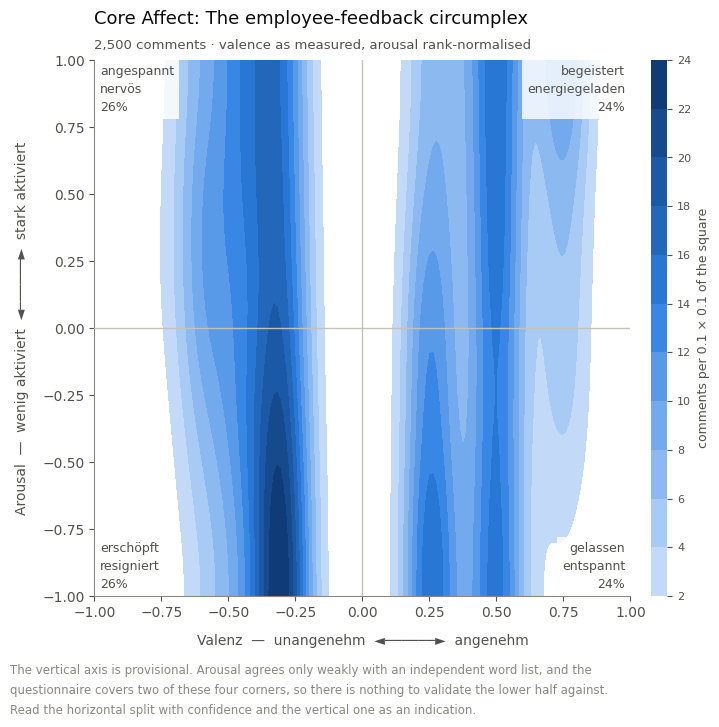

In [4]:
# ============================================================
# The Picture
# ============================================================

left, low = plot["valence"] < 0, plot["arousal"] < 0
shares = {("neg", "high"): (left & ~low).mean(), ("pos", "high"): (~left & ~low).mean(),
          ("neg", "low"): (left & low).mean(), ("pos", "low"): (~left & low).mean()}

step = 10 ** np.floor(np.log10(z.max() / 12))
step = next(m * step for m in (1, 2, 2.5, 5, 10) if z.max() / 12 <= m * step)
levels = np.arange(step, z.max() + step, step)

fig, ax = plt.subplots(figsize=(8.6, 8.0))
fig.subplots_adjust(left=0.10, right=0.88, top=0.86, bottom=0.19)

field = ax.contourf(xx, yy, z, levels=levels, cmap=DENSITY)
ax.axvline(0, color=BASELINE, lw=1, zorder=3)
ax.axhline(0, color=BASELINE, lw=1, zorder=3)

for (sign, level), label in CORNERS.items():
    ax.text(-0.98 if sign == "neg" else 0.98, 0.98 if level == "high" else -0.98,
            f"{label}\n{shares[(sign, level)]:.0%}",
            ha="left" if sign == "neg" else "right",
            va="top" if level == "high" else "bottom",
            color=INK_SOFT, fontsize=9, linespacing=1.5, zorder=4,
            bbox=dict(facecolor="white", edgecolor="none", alpha=0.82, pad=3.5))

ax.set_xlim(-1, 1)
ax.set_ylim(-1, 1)
ax.set_aspect("equal")
ax.grid(False)
ax.set_xlabel("Valenz  —  unangenehm  ◄──────►  angenehm", labelpad=10)
ax.set_ylabel("Arousal  —  wenig aktiviert  ◄──────►  stark aktiviert", labelpad=10)
ax.set_title("Core Affect: The employee-feedback circumplex", fontsize=13, loc="left", pad=26)
ax.text(0, 1.015, f"{len(plot):,} comments · valence as measured, arousal rank-normalised",
        transform=ax.transAxes, color=INK_SOFT, fontsize=9.5, va="bottom")

bar = fig.colorbar(field, ax=ax, aspect=32, pad=0.03, fraction=0.045, ticks=levels)
bar.set_label("comments per 0.1 × 0.1 of the square", color=INK_SOFT, fontsize=9)
bar.ax.tick_params(colors=INK_SOFT, labelsize=8)
bar.outline.set_visible(False)

fig.text(0.10, 0.105,
         "The vertical axis is provisional. Arousal agrees only weakly with an "
         "independent word list, and the\nquestionnaire covers two of these four "
         "corners, so there is nothing to validate the lower half against.\n"
         "Read the horizontal split with confidence and the vertical one as an "
         "indication.",
         color=INK_MUTED, fontsize=8.5, va="top", linespacing=1.7)

fig.savefig(WORK / f"{SOURCE}_circumplex.png", dpi=200, bbox_inches="tight")
plt.show()

The overall structure is dominated by valence. Most variation occurs along the horizontal axis, while differences in activation are more subtle.

Even so, the circumplex separates comments that would otherwise receive similar sentiment scores. Negative comments, for example, appear in both activated and deactivated regions of the space.

The next step quantifies these regions and examines how comments are distributed across the four quadrants.

### What the two corrections actually do

Step 2 claims both corrections are necessary rather than cosmetic. That is worth
checking, because the reader has no reason to take it on trust — and the check turns out
to be more interesting than a simple confirmation.

The same data is drawn three times below: once exactly as measured, once with the
rounding undone, and once with the boundary correction added on top. All three panels
share one colour scale, so they can be compared directly.

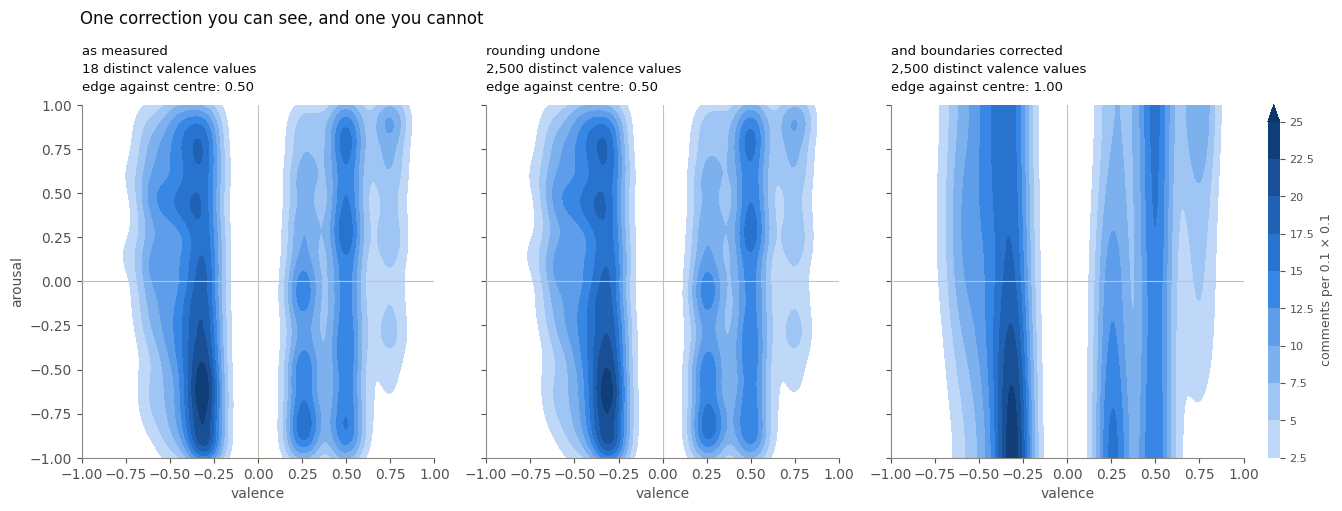

In [5]:
# ============================================================
# The Corrections, Withheld and Applied
# ============================================================

def field_for(values, mirror):
    """Density on the shared grid, optionally with the sample reflected at ±1."""
    if mirror:
        sample = np.vstack([np.concatenate([values, values, values]),
                            np.concatenate([y, 2 - y, -2 - y])])
        weight = 3
    else:
        sample = np.vstack([values, y])
        weight = 1
    density = gaussian_kde(sample, bw_method=BANDWIDTH)(
        np.vstack([xx.ravel(), yy.ravel()])).reshape(xx.shape)
    return density * weight * len(plot) * 0.01


STAGES = [
    ("as measured", plot["valence"].to_numpy(), False),
    ("rounding undone", x, False),
    ("and boundaries corrected", x, True),
]
drawn_fields = [(caption, values, field_for(values, mirror))
                for caption, values, mirror in STAGES]

# one scale for all three, otherwise the panels cannot be compared
ceiling = max(density.max() for _, _, density in drawn_fields)
step = 10 ** np.floor(np.log10(ceiling / 12))
step = next(m * step for m in (1, 2, 2.5, 5, 10) if ceiling / 12 <= m * step)
shared = np.arange(step, ceiling + step, step)

fig, axes = plt.subplots(1, 3, figsize=(13.5, 5.6))
fig.subplots_adjust(left=0.05, right=0.95, top=0.78, bottom=0.15, wspace=0.14)

for ax, (caption, values, density) in zip(axes, drawn_fields):
    drawn = ax.contourf(xx, yy, density, levels=shared, cmap=DENSITY, extend="max")
    ax.axvline(0, color=BASELINE, lw=0.8, zorder=3)
    ax.axhline(0, color=BASELINE, lw=0.8, zorder=3)
    ax.set_xlim(-1, 1)
    ax.set_ylim(-1, 1)
    ax.set_aspect("equal")
    ax.grid(False)
    ax.set_xlabel("valence")
    # the flatness of the arousal marginal is the whole point of the second correction
    profile = density.sum(axis=1)
    ax.set_title(f"{caption}\n{len(np.unique(values)):,} distinct valence values"
                 f"\nedge against centre: "
                 f"{profile[[0, -1]].mean() / profile[GRID // 2]:.2f}",
                 fontsize=9.5, loc="left", pad=10, color=INK, linespacing=1.5)

axes[0].set_ylabel("arousal")
for ax in axes[1:]:
    ax.set_yticklabels([])

bar = fig.colorbar(drawn, ax=axes, aspect=30, pad=0.02, fraction=0.022,
                   ticks=shared, format="%g")
bar.set_label("comments per 0.1 × 0.1", color=INK_SOFT, fontsize=9)
bar.ax.tick_params(colors=INK_SOFT, labelsize=8)
bar.outline.set_visible(False)

fig.suptitle("One correction you can see, and one you cannot",
             fontsize=12, x=0.05, ha="left", y=0.95, color=INK)

plt.show()

**The boundary correction is the one that shows.** The first two panels fade out towards
the top and bottom edges; the third reaches them. The number under each panel says the
same thing without the eye: the arousal marginal at the edges, divided by the marginal at
the centre. The axis is rank-normalised and therefore uniform by construction, so this
ratio has a known correct answer — 1.00. Uncorrected it is about half that, which means
the drawing was showing strong and weak activation as roughly half as common as they are.

**The de-rounding shows almost nothing, and that is not a contradiction.** It turns 18
distinct valence values into 2,500, but the kernel is wider than the 0.05 grid the score
arrives on, so it had already smoothed the fine comb away before the jitter was applied.
The correction matters for what the estimate is fed rather than for what this particular
drawing looks like — and it becomes visible as soon as the kernel is narrowed or the
points are drawn directly. Notebook 02 shows the comb itself.

**The coarse vertical bands survive all three panels, and they are supposed to.** They
are not the grid. They are genuine gaps in what the language model is willing to output —
it will say −0.25 and it will say 0.00, but almost nothing in between. The jitter spans
half a grid step and cannot close a gap five times that wide, exactly as Step 2 states.

## Step 3 — The same thing as numbers

The circumplex is easier to read visually than numerically, but the underlying proportions are worth reporting explicitly. The table below shows how comments are distributed across the four regions of the affect space.

In [6]:
# ============================================================
# Corner Shares
# ============================================================

table = pd.DataFrame([
    {"corner": label.replace("\n", " / "),
     "valence": "unpleasant" if sign == "neg" else "pleasant",
     "activation": "high" if level == "high" else "low",
     "comments": int(round(share * len(plot))),
     "share %": round(share * 100, 1)}
    for (sign, level), label in CORNERS.items()
    for share in [shares[(sign, level)]]
]).sort_values("comments", ascending=False).reset_index(drop=True)

print(table.to_string(index=False))
print(f"\nunpleasant in total: "
      f"{table.loc[table['valence'] == 'unpleasant', 'share %'].sum():.1f} %")
print("The activation split is the corpus median by construction, so the two halves")
print("hold 50 % each and the whole imbalance sits on the valence axis.")

                     corner    valence activation  comments  share %
        angespannt / nervös unpleasant       high       649     26.0
     erschöpft / resigniert unpleasant        low       647     25.9
begeistert / energiegeladen   pleasant       high       602     24.1
       gelassen / entspannt   pleasant        low       602     24.1

unpleasant in total: 51.9 %
The activation split is the corpus median by construction, so the two halves
hold 50 % each and the whole imbalance sits on the valence axis.


The distribution is almost perfectly balanced across the four regions of the circumplex. This is expected for the activation dimension, which was rank-normalised and therefore splits the corpus into two equally sized halves.

The only visible imbalance occurs on the valence axis, where slightly more comments fall on the unpleasant side (51.9%) than on the pleasant side (48.1%).

This means that the synthetic corpus is characterised more by differences in pleasantness than by differences in activation.

## Step 4 — Why valence is not rank-normalised as well

Putting both axes on percentile ranks makes the picture look like a textbook
circumplex: the points fill the square evenly. It is tempting and it is wrong.

Rank-normalising makes a distribution uniform **by construction**. Do it to both axes
and each corner is pushed towards 25 % — the chart then describes the transformation
rather than the comments.

There is a sharper objection. If most comments are unpleasant, the median comment is
itself an unpleasant one, and ranking puts the median at the centre of the axis.
Every unpleasant comment above that median is pushed across zero into the pleasant
half. How many depends on how skewed the corpus is; the cell below counts them for
this one.

In [7]:
# ============================================================
# What Ranking Valence Would Do
# ============================================================

ranked = plot["valence"].rank(pct=True) * 2 - 1

misplaced = ((plot["valence"] < 0) & (ranked > 0)).sum()
opposite = ((plot["valence"] > 0) & (ranked < 0)).sum()

print(f"comments that are unpleasant but would rank as pleasant: {misplaced:,} "
      f"({misplaced / len(plot):.0%})")
print(f"comments that are pleasant but would rank as unpleasant: {opposite:,} "
      f"({opposite / len(plot):.0%})")

ranked_left, ranked_low = ranked < 0, plot["arousal"] < 0
print(f"\n{'corner':30s} {'as measured':>12s} {'both ranked':>12s}")
for (sign, level), label in CORNERS.items():
    as_is = shares[(sign, level)]
    mask_left = ranked_left if sign == "neg" else ~ranked_left
    mask_low = ranked_low if level == "low" else ~ranked_low
    print(f"{label.replace(chr(10), ' / '):30s} {as_is:11.0%} "
          f"{(mask_left & mask_low).mean():11.0%}")

comments that are unpleasant but would rank as pleasant: 63 (3%)
comments that are pleasant but would rank as unpleasant: 0 (0%)

corner                          as measured  both ranked
angespannt / nervös                    26%         25%
begeistert / energiegeladen            24%         25%
erschöpft / resigniert                 26%         24%
gelassen / entspannt                   24%         26%


Even in this nearly balanced corpus, 63 comments (3%) would be moved across the valence boundary by rank-normalisation.

The effect is modest here because positive and negative comments are distributed relatively evenly. In a more strongly skewed corpus, substantially more comments would be reassigned to the opposite side of the axis, potentially changing the overall interpretation.

## Step 5 — Hand over

In [8]:
# ============================================================
# Export
# ============================================================

sign = np.where(data["valence"] < 0, "neg", "pos")
level = np.where(data["arousal"] < 0, "low", "high")
data["corner"] = [CORNERS.get((s, l), "").replace("\n", " / ")
                  if pd.notna(v) and pd.notna(a) else None
                  for s, l, v, a in zip(sign, level, data["valence"], data["arousal"])]

data.to_parquet(OUTPUT, index=False)
table.to_csv(WORK / f"{SOURCE}_circumplex_corners.csv", index=False, sep=";",
             encoding="utf-8-sig", decimal=",")
print(f"written: {OUTPUT.name}, {SOURCE}_circumplex_corners.csv, "
      f"{SOURCE}_circumplex.png")

written: synthetic_circumplex.parquet, synthetic_circumplex_corners.csv, synthetic_circumplex.png


## Key Findings

**The two dimensions can be combined into the circumplex the project set out to build.** The resulting space preserves the strong valence measure from Notebook 02 while adding a second, largely independent dimension from Notebook 03.

**Valence remains the stronger of the two axes.** Its interpretation is supported by direct validation against survey responses and can be used with confidence when comparing comments, departments, or survey waves.

**Arousal adds information, but should be interpreted cautiously.** The selected measure remains largely independent of valence, yet its agreement with external references is only modest and the available survey data provide limited validation opportunities.

**The circumplex is therefore more reliable horizontally than vertically.** The left-right split reflects meaningful differences in pleasantness, whereas the upper-lower split should be read as an indication of relative activation within the corpus rather than a precise measure of activation.

**The visualisation requires methodological corrections.** Jittering removes artefacts introduced by the language model's rounded valence scores, and boundary correction prevents the density estimate from understating extreme arousal values. Both adjustments improve the accuracy of the visualisation without changing its substantive interpretation.

**Rank-normalising valence would distort the result.** Unlike arousal, valence has a meaningful zero point. Converting it to percentile ranks would move comments across the neutral boundary and alter the balance between pleasant and unpleasant feedback.

---

### Against the Real Data

**This notebook has no direct comparison, deliberately.** The distribution of comments across the circumplex is itself an organisational finding. Reporting the real corner shares alongside the synthetic ones would reveal exactly the information the synthetic dataset was created to protect.

What does carry over is the method. The same valence measure, the same arousal measure, the same asymmetric scaling, and the same visual corrections are applied to both datasets. Anyone running the notebook on a different survey receives their own circumplex, constructed in exactly the same way.